In [8]:
# Import the libraries into this project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This special line tells Jupyter to show your charts directly inside the notebook page
%matplotlib inline

In [14]:
# Load the main population tracking table
pop_df = pd.read_csv("API_SP.POP.TOTL_DS2_en_csv_v2_267553.csv", skiprows=4)
# Load the country metadata table
meta_df = pd.read_csv('Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_267553.csv')
# Look at the first 3 rows of the data to make sure it loaded properly
pop_df.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN


In [15]:
# Merge both files together into a single table using the unique 'Country Code' column
merged_df = pd.merge(pop_df, meta_df, on='Country Code')

# Drop rows where 'Region' is blank. This cleans out global summaries like "World" or "High income" groups
countries_df = merged_df.dropna(subset=['Region'])

# Print a message to confirm it worked
print("Data successfully merged! Total countries remaining:", len(countries_df))

Data successfully merged! Total countries remaining: 217


C:\Users\Vinit\AppData\Local\Temp\ipykernel_20340\209095648.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2023', y='Region', data=region_distribution, palette='viridis')


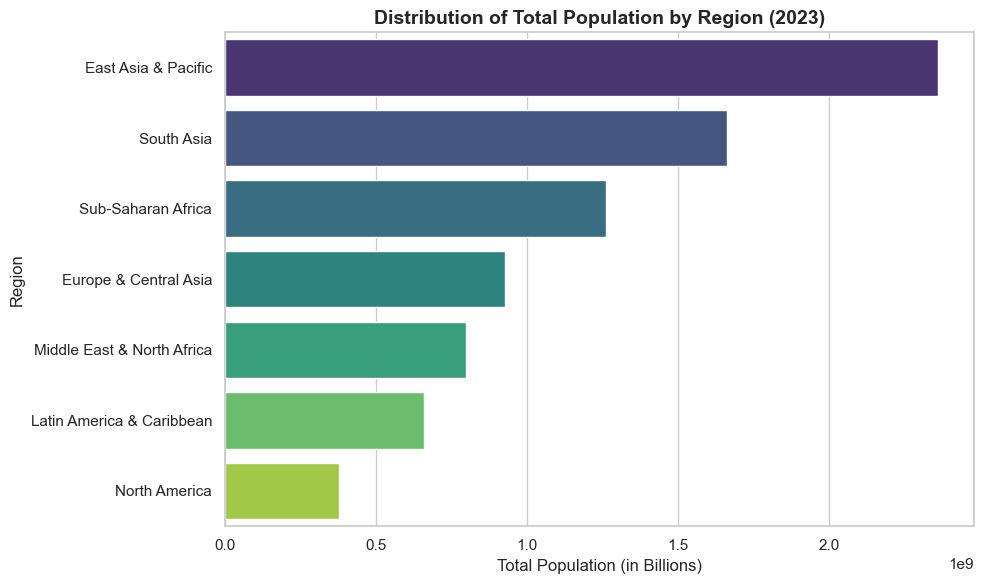

In [17]:
# Group data by 'Region' and add up all country populations for the year 2023
region_distribution = countries_df.groupby('Region')['2023'].sum().sort_values(ascending=False).reset_index()

# Set up the sizing of our canvas window
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") # Adds a clean background grid

# Draw a horizontal bar plot
sns.barplot(x='2023', y='Region', data=region_distribution, palette='viridis')

# Add decorative text elements
plt.title('Distribution of Total Population by Region (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Total Population (in Billions)', fontsize=12)
plt.ylabel('Region', fontsize=12)

# Display the final image inside your notebook
plt.tight_layout()
plt.show()

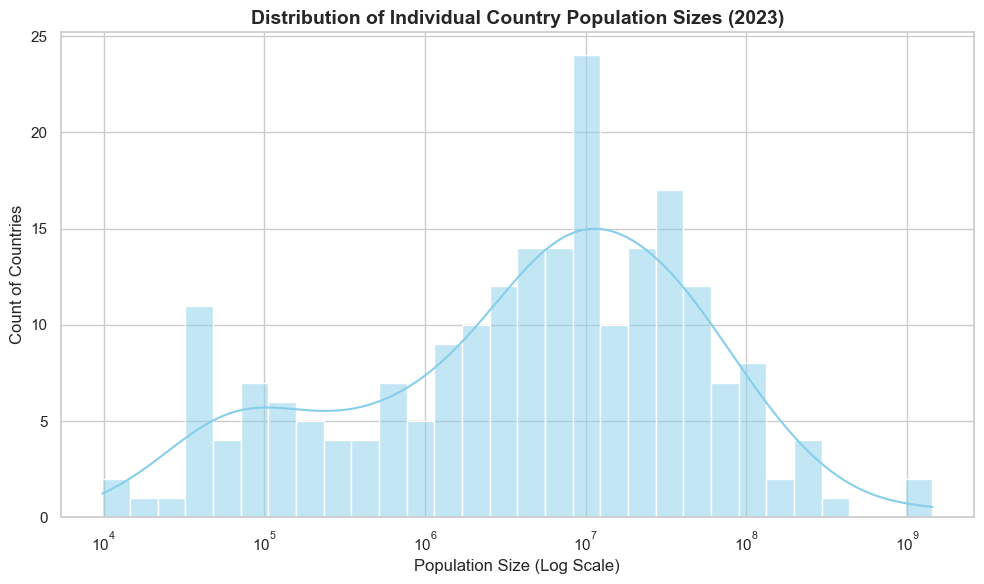

In [18]:
# Set up the canvas sizing
plt.figure(figsize=(10, 6))

# Draw the histogram with an added smooth trend line (kde=True)
sns.histplot(countries_df['2023'], bins=30, kde=True, color='skyblue', log_scale=True)

# Add titles and labels
plt.title('Distribution of Individual Country Population Sizes (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Population Size (Log Scale)', fontsize=12)
plt.ylabel('Count of Countries', fontsize=12)

# Display the final image
plt.tight_layout()
plt.show()

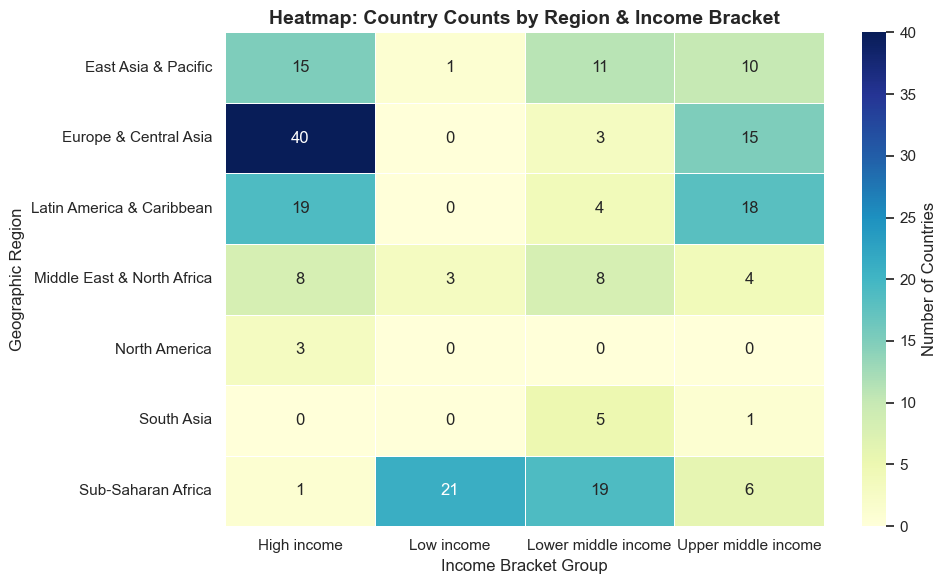

In [19]:
# 1. Create a cross-tabulation table (contingency table) counting countries
# This builds a matrix grid of Regions (rows) vs Income Groups (columns)
region_income_matrix = pd.crosstab(countries_df['Region'], countries_df['IncomeGroup'])

# Set up the size of our canvas
plt.figure(figsize=(10, 6))

# 2. Draw the heatmap
# 'annot=True' prints the actual count number inside each colorful square
# 'cmap' defines the color palette gradient (e.g., 'Blues', 'YlGnBu', 'magma')
# 'fmt='d'' ensures the numbers are printed as clean integers instead of decimals
sns.heatmap(
    region_income_matrix, 
    annot=True, 
    cmap='YlGnBu', 
    fmt='d', 
    linewidths=0.5, 
    cbar_kws={'label': 'Number of Countries'}
)

# Add titles and labels
plt.title('Heatmap: Country Counts by Region & Income Bracket', fontsize=14, fontweight='bold')
plt.xlabel('Income Bracket Group', fontsize=12)
plt.ylabel('Geographic Region', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()

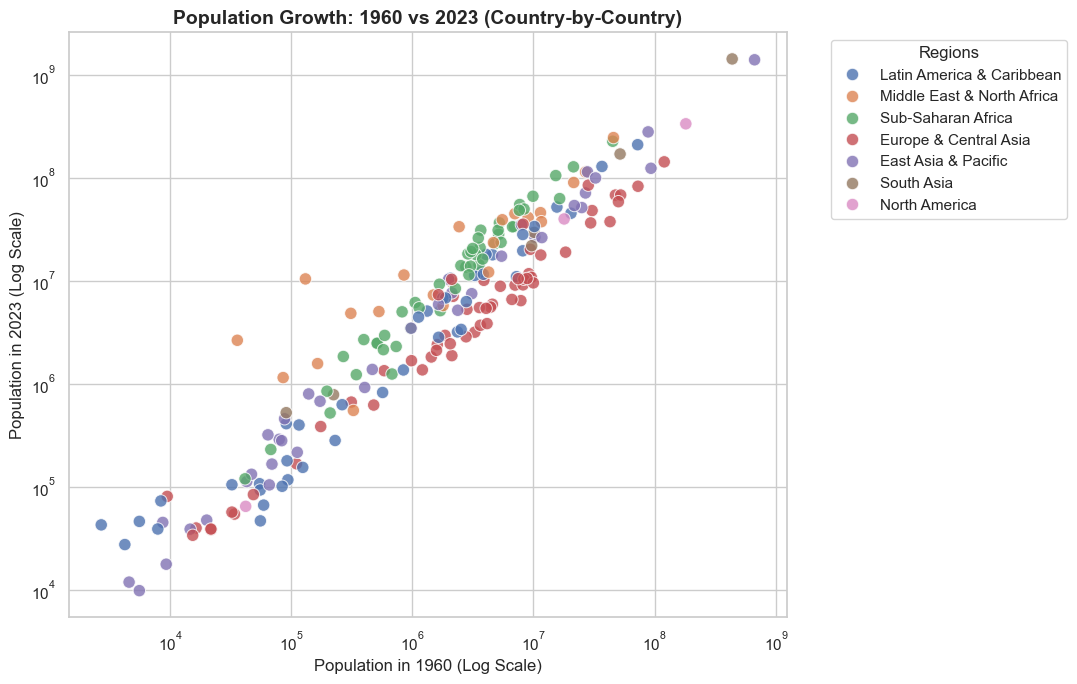

In [20]:
# Set up the size of our canvas
plt.figure(figsize=(11, 7))

# Create the scatter plot
# 'hue' colors the dots automatically based on their geographic Region
sns.scatterplot(
    x='1960', 
    y='2023', 
    hue='Region', 
    data=countries_df, 
    alpha=0.8, 
    s=80  # 's' sets the size of the dots
)

# Apply a logarithmic scale to both axes so small and large countries are distributed evenly
plt.xscale('log')
plt.yscale('log')

# Add descriptive labels and title
plt.title('Population Growth: 1960 vs 2023 (Country-by-Country)', fontsize=14, fontweight='bold')
plt.xlabel('Population in 1960 (Log Scale)', fontsize=12)
plt.ylabel('Population in 2023 (Log Scale)', fontsize=12)

# Place the region color legend nicely outside the main chart area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Regions')

# Display the chart
plt.tight_layout()
plt.show()